# Example 1: fitting a single planet (51 Pegasi b)

To show how to fit some RV data, let's start with possibly the most famous exoplanet, 51 Peg b. We will quickly fit a circular model, find a best-fit solution using MAP, explore parameter uncertainty with MCMC, and derive a mass-estimate $M_p\sin{i}$.

The ELODIE data and parameters used in this example notebook for 51 Peg b were obtained from [Birkby et al. 2017](http://doi.org/10.3847/1538-3881/aa5c87).

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.stats import knuth_bin_width

import ravest.prior
import ravest.param
from ravest.fit import Fitter
from ravest.model import calculate_mpsini
from ravest.param import Parameter, Parameterisation

> **Important:** to keep this example quick to run and its outputs reproducible, it takes two shortcuts that you should **not** copy in your own fits:
>
> - **Few walkers and short chains.** The MCMC runs here use far fewer walkers, and far fewer steps, than a real fit would. Ravest requires at least $2\times$ the number of free parameters; for real fits a couple of hundred walkers is a sensible starting point, and you should run until the chains have converged (e.g. `check_convergence=True` in `run_mcmc`).
> - **A fixed random seed.** The next cell (collapsed on the website) fixes NumPy's random seed so that re-running this notebook gives identical results. **Remove it in your own fits: never freeze the random seed for real analysis.**

In [ ]:
# WARNING: this fixes NumPy's random seed ONLY so this tutorial's outputs are reproducible.
# Do NOT copy this into your own fits: remove it, and do not freeze the random seed.
np.random.seed(42)

## Load and inspect the RV data

In [ ]:
fpath = Path.cwd() / "example_data" / "51Pegb.txt"
data = pd.read_csv(fpath, delimiter='\s+')
# Convert to BTJD (Barycentric TESS Julian Date) by subtracting 2457000
data["time"] = data["time"] - 2457000
data

,time,vel,verr,tel
0,-7389.467245,-33258.0,9.0,ELODIE
1,-7387.528344,-33225.0,9.0,ELODIE
2,-7344.688737,-33272.0,7.0,ELODIE
3,-7271.772638,-33310.0,7.0,ELODIE
4,-7270.775020,-33248.0,7.0,ELODIE
...,...,...,...,...
148,-4387.643306,-33266.0,8.0,ELODIE
149,-4166.392013,-33315.0,7.0,ELODIE
150,-4147.379446,-33196.0,7.0,ELODIE
151,-4141.412989,-33300.0,8.0,ELODIE


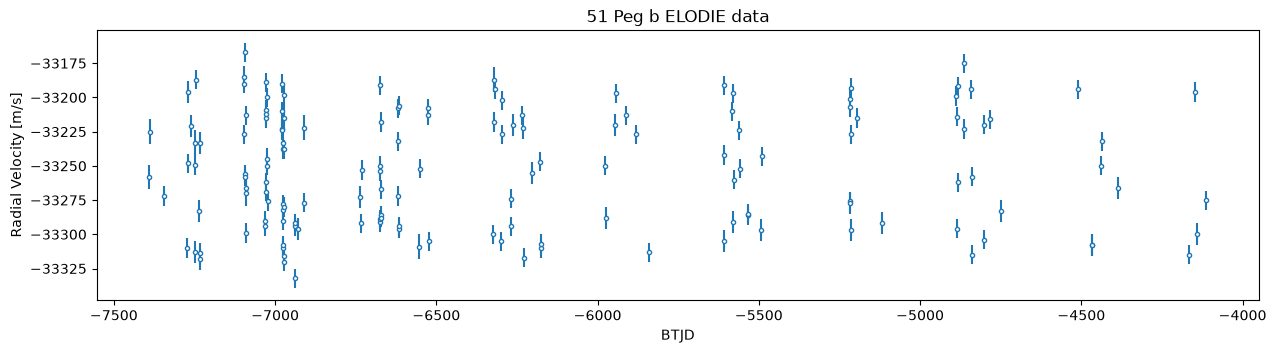

In [ ]:
plt.figure(figsize=(15,3.5))
plt.title("51 Peg b ELODIE data")
plt.ylabel("Radial Velocity [m/s]")
plt.xlabel("BTJD")
plt.errorbar(data["time"], data["vel"], yerr=data["verr"], marker=".", linestyle="None", mfc="white")
plt.show()

## Set up the RV Fitter

Here we create and configure a `Fitter` object, which allows you to define how many planets are in the model, which parameters are being fitted, the parameterisation used, initial parameter values for a MAP fit, and define the priors on free parameters. It will also check the data format and that each free parameter has priors.

The constructor takes:
- `planet_letters`: this defines how many planets are in the model based on how many letters you provide.
- `parameterisation`: this defines which parameterisation you are fitting in. Specifically, whether you want to sample eccentricity in $e$ and $\omega_\star$, or in $\sqrt{e}\cos\omega_\star$ and $\sqrt{e}\sin\omega_\star$, and whether you want to sample time of periastron passage $T_\text{P}$ or mid-transit time $T_\text{C}$ (technically the time of inferior conjunction). The list of available parameterisations is printed below.

In [ ]:
print("Allowed parameterisations:", ravest.param.ALLOWED_PARAMETERISATIONS)

Allowed parameterisations: ['P K e w Tp', 'P K e w Tc', 'P K secosw sesinw Tp', 'P K secosw sesinw Tc']


As a *very* brief recap, the Radial Velocity equation for a planet (used in Ravest, at least) at time $t_i$ is:
  
$$ v(t_i) = K \left[ \cos(\nu(t_i)+\omega_\star)+e\cos\omega_\star \right]$$
  
where $K$ is the semi-amplitude (m/s), $e$ is the eccentricity, $\omega_\star$ is the argument of periastron (radians), and $\nu(t_i)$ is the true anomaly -- of which the only thing you need to know about here is that it requires the orbital period $P$ (days) and the time of periastron passage $T_\text{P}$ (Julian Date).

The RV contribution $v(t_i)$ from each planet is independent and summed. Then, the instrument that took the observation at time $t_i$ will have its own systemic offset velocity $\gamma_\text{inst}$, and a "jitter" value $\sigma_\text{jit, inst}$. Finally, an overall system trend (linear $\dot{\gamma}$ and/or quadratic $\ddot{\gamma}$) can be included too against an arbitrary reference time $t_0$ (often the mean of the observations), to account for instrumental drift, long term companions, etc. This is also summed to the planetary RVs, to yield the final radial velocity, in metres per second:
  
$$ \mu_i = v(t_i) + \gamma_\mathrm{inst} + \dot{\gamma}(t_i - t_0) + \ddot{\gamma}(t_i - t_0)^2 $$

Although the radial velocity equation uses $P$, $K$, $e$, $\omega_\star$ and $T_\text{P}$, in practice when fitting eccentric orbits, you'll likely want to use the $\sqrt{e}\cos\omega_\star$ and $\sqrt{e}\sin\omega_\star$ parameterisation, to mitigate the Lucy-Sweeney bias and speed up convergence times. For transiting planets with a well constrained transit time $T_\text{C}$, you'll also likely want to fit (or fix) that, as a directly observable quantity, rather than use $T_\text{P}$. Ravest handles all of the conversions internally. As we are doing a quick circular fit here, we'll use `"P K e w Tc"`.

In [ ]:
fitter = Fitter(
    planet_letters=["b"],  # Just the one planet
    parameterisation=Parameterisation("P K e w Tc")  # sample transit time Tc instead of periastron time Tp
    )

The `add_data` method then takes:
- `time`, `vel` and `velerr` which are the time, RV and measured RV uncertainty ("error bar") columns of your data.
- `instrument`, which tells Ravest which RV measurement is from which instrument. This also tells Ravest which `jit` $\sigma_\text{jit}$ and offset `g` $\gamma$ parameters it should expect.
- `t0`, the reference time $t_0$ for the linear and quadratic trend parameters $\dot{\gamma}$ and $\ddot{\gamma}$. Setting this at the mean of your RV data's times is generally a good choice.

In [ ]:
# Load the data into the fitter.
fitter.add_data(time=data["time"].to_numpy(), 
                vel=data["vel"].to_numpy(), 
                velerr=data["verr"].to_numpy(), 
                instrument=data["tel"].to_numpy(),  # If you have multiple instruments, this is how Ravest identifies which data points belong to which instrument.
                t0=np.mean(data["time"]))  # t0 is the reference time for linear and quadratic trends. The mean of the RV data is generally a good choice.
print("t0:", fitter.t0)

t0: -6243.54519806536


### Parameters and priors

The `params_dict` then needs a `Parameter` object for each parameter your model requires. This will be the five `parameterisation` parameters for each planet, the offset `g` and jitter `jit` parameters for each instrument, and the system linear trend `gd` and quadratic trend `gdd` parameters. You can declare whether a parameter is sampled in the MCMC or not by setting `fixed`.

The initial values set in `params_dict` will be the adopted value for a fixed parameter, or the initial guess for a MAP fit for free parameters.

In [ ]:
# Construct the params dict
# These values will be used as your values for fixed parameters, or the initial guess for the MAP fit for free parameters.
params_dict = {
          # Planet b parameters
          "P_b": Parameter(4.23, "d", fixed=False),
          "K_b": Parameter(60, "m/s", fixed=False),
          "e_b": Parameter(0, "", fixed=True),
          "w_b": Parameter(np.pi/2, "rad", fixed=True),
          "Tc_b": Parameter(2456325.94 - 2457000, "d", fixed=False),  # Converting to BTJD to make labels easier to read.

          # ELODIE instrument parameters
          "g_ELODIE": Parameter(np.median(fitter.vel), "m/s", fixed=False),
          "jit_ELODIE": Parameter(0, "m/s", fixed=True),

          # System trend parameters
          "gd": Parameter(0, "m/s/day", fixed=True),
          "gdd": Parameter(0, "m/s/day^2", fixed=True),
          }

# Add the params dict to the fitter
fitter.params = params_dict
fitter.params

{'P_b': Parameter(value=4.23, unit='d', fixed=False),
 'K_b': Parameter(value=60, unit='m/s', fixed=False),
 'e_b': Parameter(value=0, unit='', fixed=True),
 'w_b': Parameter(value=1.5707963267948966, unit='rad', fixed=True),
 'Tc_b': Parameter(value=-674.0600000000559, unit='d', fixed=False),
 'g_ELODIE': Parameter(value=np.float64(-33252.0), unit='m/s', fixed=False),
 'jit_ELODIE': Parameter(value=0, unit='m/s', fixed=True),
 'gd': Parameter(value=0, unit='m/s/day', fixed=True),
 'gdd': Parameter(value=0, unit='m/s/day^2', fixed=True)}

Next, we need to add prior functions for the free parameters. Ravest has a range of prior functions available:

In [ ]:
ravest.prior.PRIOR_FUNCTIONS

['Uniform',
 'EccentricityUniform',
 'Normal',
 'TruncatedNormal',
 'HalfNormal',
 'Rayleigh',
 'VanEylen19Mixture',
 'Beta']

Like model parameters, this is also passed to `Fitter` as a dict. It will also check that all free parameters have a prior, and that a prior hasn't accidentally been declared for a fixed parameter.

In [ ]:
# Construct the priors dict. Every parameter that isn't fixed requires a prior.
priors_dict = {
          "P_b": ravest.prior.Normal(params_dict["P_b"].value, 0.000001),
          "K_b": ravest.prior.Uniform(lower=0, upper=100),
          "Tc_b": ravest.prior.Uniform(lower=params_dict["Tc_b"].value-2.0, upper=params_dict["Tc_b"].value+2.0),
          "g_ELODIE": ravest.prior.Uniform(lower=params_dict["g_ELODIE"].value-np.std(fitter.vel), upper=params_dict["g_ELODIE"].value+np.std(fitter.vel)),
        }

# Add the priors dict to the fitter. This will check for any missing or unexpected priors and raise an error if needed.
fitter.priors = priors_dict
fitter.priors

{'P_b': Normal(mean=4.23, std=1e-06),
 'K_b': Uniform(lower=0, upper=100),
 'Tc_b': Uniform(lower=-676.0600000000559, upper=-672.0600000000559),
 'g_ELODIE': Uniform(lower=-33293.6610064078, upper=-33210.3389935922)}

## Fitting to the data

### The initial MAP fit

Now that we have loaded the `Fitter` with the data, our parameterisation, our initial parameter values, and priors for each of the free parameters, we can now fit the free parameters of the model to the data. 

First, a quick Maximum A Posteriori (MAP) optimisation is performed to find the best-fit solution that maximises the log-probability (log likelihood + log priors). This gives us a good starting point to initialise the MCMC walkers around later.

In [ ]:
map_result = fitter.find_map_estimate(method="Powell")
map_result

MAP parameter results: {'P_b': np.float64(4.230000383665818), 'K_b': np.float64(55.70905061542831), 'Tc_b': np.float64(-674.1092511101302), 'g_ELODIE': np.float64(-33251.24252216133)}


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 794.802645093951
       x: [ 4.230e+00  5.571e+01 -6.741e+02 -3.325e+04]
     nit: 3
   direc: [[ 1.000e+00  0.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]
    nfev: 115

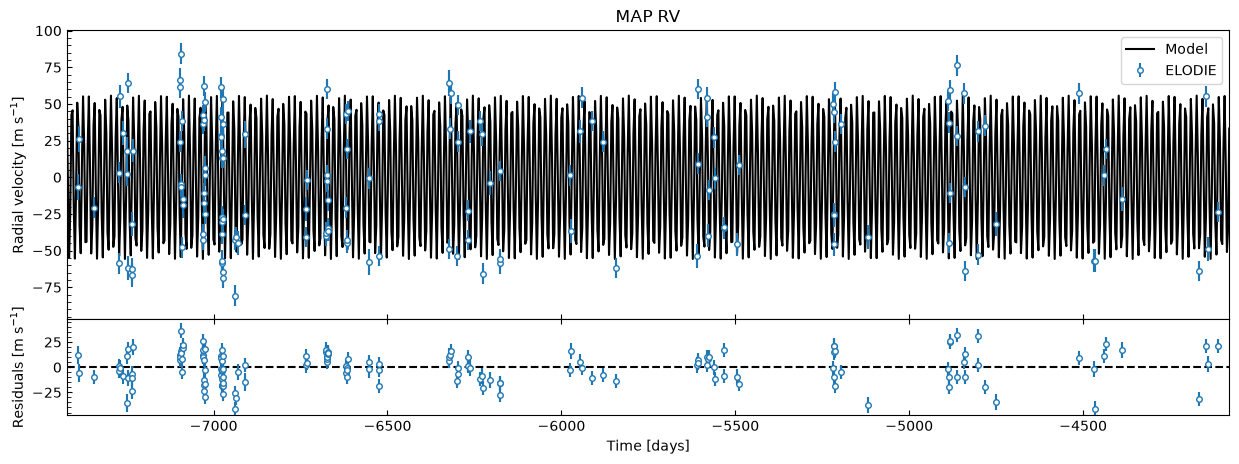

In [ ]:
fitter.plot_MAP_rv(map_result=map_result, save=False)

The residuals look okay, but because of how spread out the data is over time, it's hard to really gauge how well the planet Keplerian model is fitting to the data. So let's create an orbital phase plot: fold the data over the orbital period $P$ around the mid-transit (inferior conjunction) time $T_\text{C}$, and show just the RV contribution of the planet (subtracting any system trend).

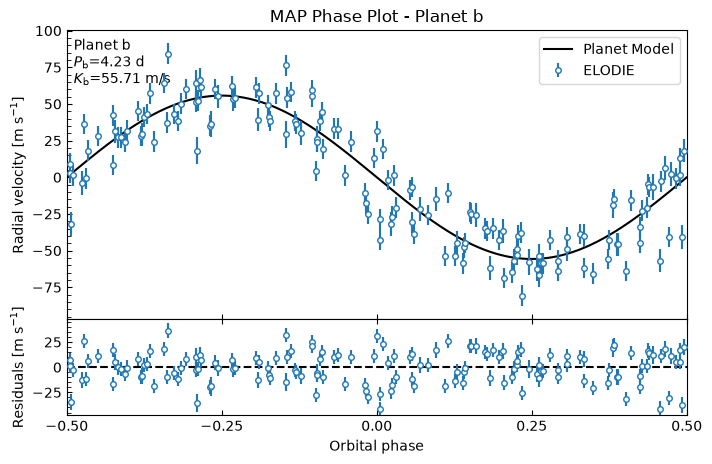

In [ ]:
fitter.plot_MAP_phase(map_result=map_result, planet_letter="b", save=False)

That looks like a reasonable fit already! (Not a huge surprise, given that we initialised the parameters close to the correct values...)

### The main MCMC fit

Next, MCMC is used to explore the parameter space to estimate the parameter uncertainties and fully explore the parameter space. We can initialise the walkers in a small ball around our MAP values using the function `generate_initial_walker_positions_from_map`. They will still spread out and explore the function space. It also ensures each walker starts in a position that both satisfies the boundaries of the prior functions, and that is astrophysically valid (e.g. still satifies $P>0$ or $0\leq{e}<1$.)

There is also a function `generate_initial_walker_positions_random`, that randomly spreads the initial positions within the prior ranges. You can also supply a set of values to `generate_initial_walker_positions_around_point` and it will make a set of values for each walker around the points you provided (like the `...from_map()` version does from the MAP results).

Alternatively, you can supply your own starting values for each walker to the `run_mcmc` command directly, but you need to be careful that they are physically valid and that they satisfy the walkers. It is **strongly recommended** that you fuzz the values in these cases - do not pass identical values for each walker to the MCMC!

In [ ]:
nwalkers = 2 * len(fitter.free_params_dict)  # Minimum number of walkers is 2 * number of free params. You probably want at least one hundred though!
mcmc_init = fitter.generate_initial_walker_positions_from_map(map_result=map_result, nwalkers=nwalkers, scale=1e-5)

You'll likely want to run your real MCMC with considerably more steps than this. A small number was chosen here to keep the notebook computation time to a minimum. Furthermore, you'll also want considerably more walkers (at least one hundred!) Also remember that in all of these example notebooks, NumPy has a set seed so that they are reproducible (the `np.random.seed(42)` line at the top of this notebook) - **do not do this in your own fits!** This is only so that these example notebooks always produce the same numbers when re-run.

In [ ]:
max_steps = 15_000  # You probably want to run for much longer than this!
samples = fitter.run_mcmc(initial_positions=mcmc_init, nwalkers=nwalkers, max_steps=max_steps, progress=True,)  # This will take a while!

INFO:root:Starting MCMC for 15000 steps...
100%|██████████| 15000/15000 [00:03<00:00, 4963.14it/s]
INFO:root:...MCMC done.


## Inspect the results

### Getting the MCMC samples

Now that the MCMC is finished, the `emcee` sampler has been saved into the `Fitter` object. We can therefore interact with it in the usual way to export the samples, as a numpy array that can be passed into other functions (such as for comparing two models by estimating the log Bayesian evidence $\ln\mathcal{Z}$ - see [Example 4: using the Learned Harmonic Mean Estimator](https://ravest.readthedocs.io/en/latest/Examples/example_4_harmonic.html)). We can also export them into a Pandas dataframe, which keeps each parameter labelled. In both cases, we can pass in the `discard_start` and `thin` arguments as desired.

In [ ]:
# Get the results from the sampler, as a numpy array. Discard the burn-in phase, thin the chains.
nburn = 1_000
thin_rate = 10

samples = fitter.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate)
print(samples.shape)  # (nsteps, nwalkers, nparams)

# Get the (flattened) samples as a labelled Pandas dataframe
samples_df = fitter.get_samples_df(discard_start=nburn, discard_end=0, thin=thin_rate)
samples_df  # shape (nsteps*nwalkers, nparams)

(1400, 8, 4)


,P_b,K_b,Tc_b,g_ELODIE
0,4.229999,56.259010,-674.107640,-33251.067399
1,4.229998,55.991991,-674.111215,-33251.946911
2,4.230001,56.212374,-674.102028,-33250.708957
3,4.230000,54.755205,-674.109078,-33250.539955
4,4.230003,55.607481,-674.099928,-33251.308224
...,...,...,...,...
11195,4.229999,55.881075,-674.115913,-33251.729756
11196,4.229999,55.302243,-674.108576,-33250.476676
11197,4.230000,55.919401,-674.106962,-33251.625384
11198,4.230001,55.710976,-674.099678,-33250.913910


### MCMC diagnostics

#### Chain trace plots

To inspect the chains visually, we can plot (and optionally save) the time series of each parameter in the chain. If you want to overplot a value for each parameter (such as the MAP solution or some published values), you can pass a list to the `truths` argument, e.g. `truths=map_result.x`.

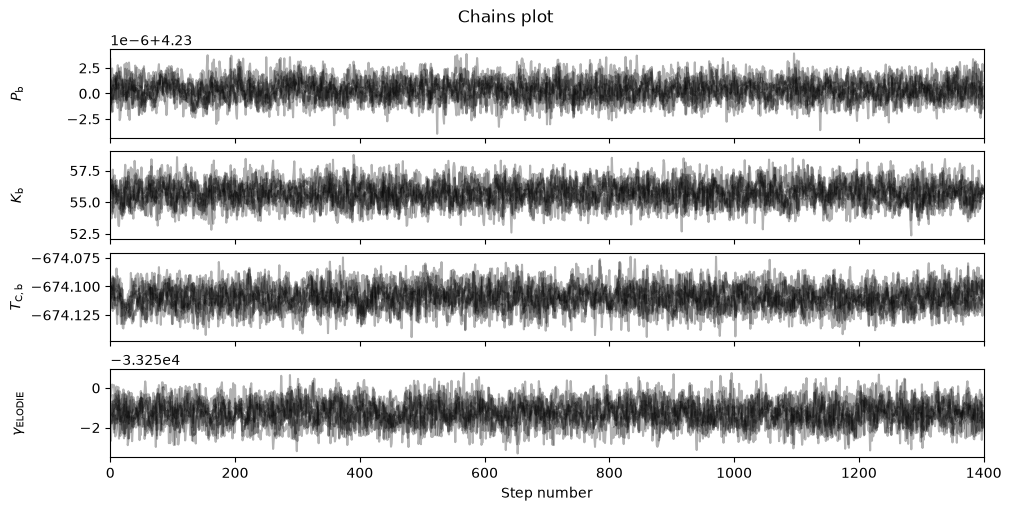

In [ ]:
fitter.plot_chains(discard_start=nburn, discard_end=0, thin=thin_rate, save=False)

These look very well-mixed: you can zoom in on the burn-in period by changing `discard_start` to 0 and `discard_end` argument to instead discard everything *after* the burn-in period, to see that the walkers did initialise converged around the MAP, but quickly started exploring the parameter space around the solution.

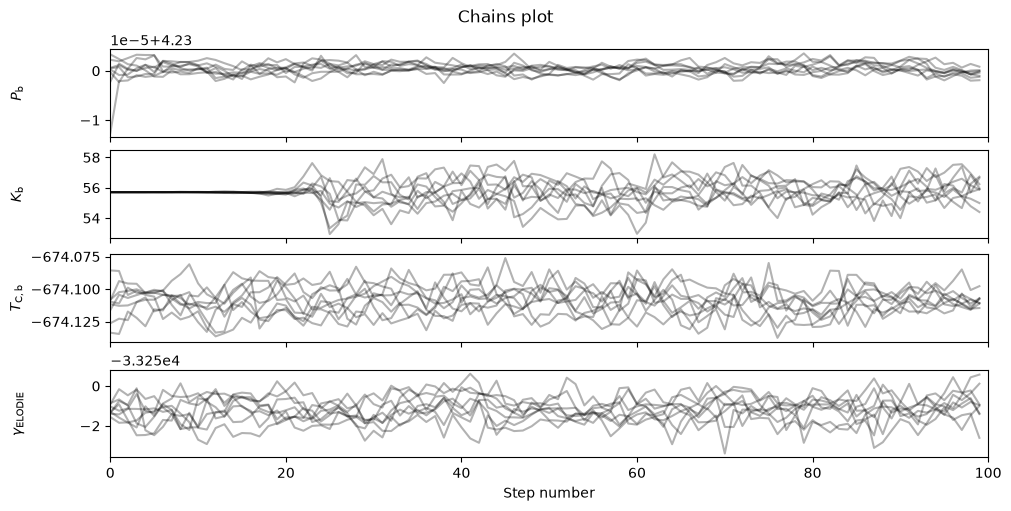

In [ ]:
fitter.plot_chains(discard_start=0, discard_end=max_steps-nburn, thin=thin_rate, save=False)

#### Compare the "best" sample values to the MAP values

One quick check we can do is get the parameter values at the sample with the best (highest) log probability. We can compare these to the MAP values, they should be nearly identical - if not, maybe the MAP got stuck in a local maximum?

In [ ]:
best_lnprob_params = fitter.get_sample_with_best_lnprob(discard_start=nburn, discard_end=0, thin=thin_rate)
MAP_params = dict(zip(fitter.free_params_dict.keys(), map_result.x))
print("Best sample param values:", best_lnprob_params)
print(" MAP result param values:", MAP_params)

Best sample found with log probability -794.816309 at index 5943 of samples (with discard_start=1000, discard_end=0, thin=10)
Best sample param values: {'P_b': np.float64(4.230000259798136), 'K_b': np.float64(55.71824461567804), 'Tc_b': np.float64(-674.1097921199714), 'g_ELODIE': np.float64(-33251.30245541845)}
 MAP result param values: {'P_b': np.float64(4.230000383665818), 'K_b': np.float64(55.70905061542831), 'Tc_b': np.float64(-674.1092511101302), 'g_ELODIE': np.float64(-33251.24252216133)}


### Results

#### Corner plots

We can also visualise the posterior parameter distributions in corner plots, using the `corner` module. If you want to see how the parameter distributions compared to the MAP solution, pass `truths=map_result.x` as an argument. This can be a useful diagnostic to check the MAP didn't get stuck in a local maximum. You could also pass in published parameter values to compare to your distributions.

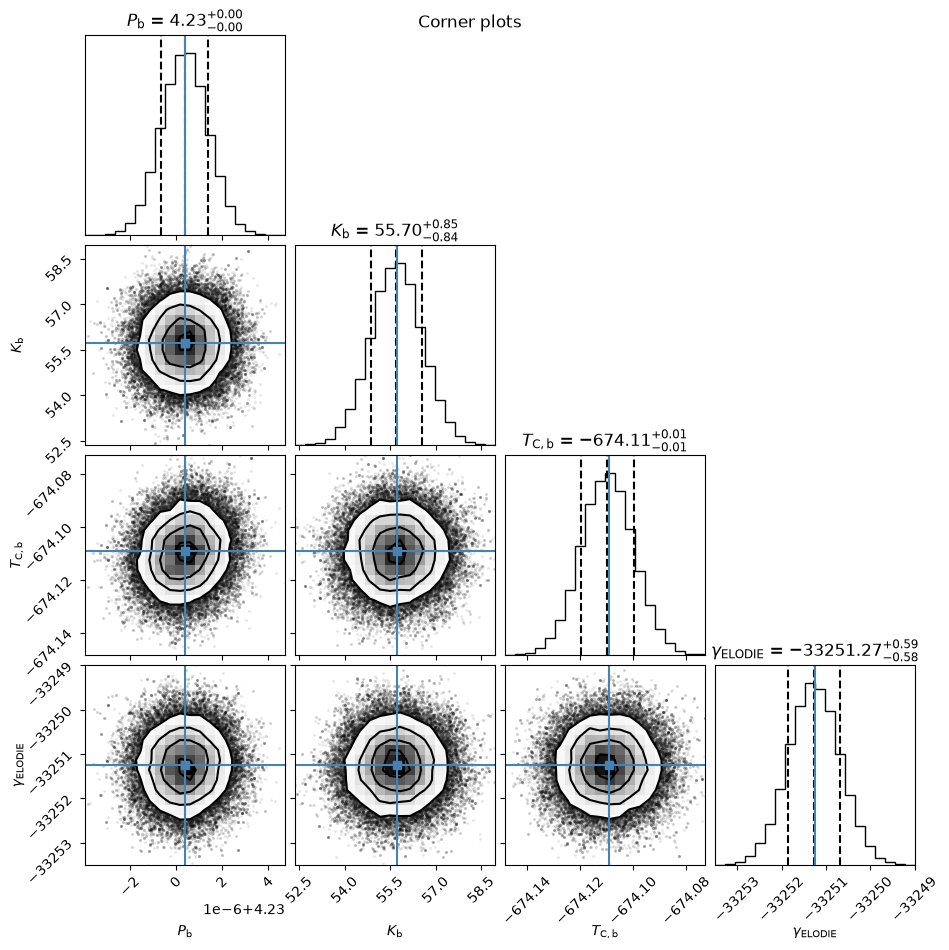

In [ ]:
fitter.plot_corner(discard_start=nburn, truths=map_result.x, plot_datapoints=True, save=False)

In this case, the automatically generated value and error (the 16th, 50th and 84th percentiles) are fairly representative, but you should always inspect the posterior corner plots as distributions won't always be normal/symmetric. For further analysis and inspection, recall we can get a dataframe of the samples with the `Fitter.get_samples_df()` method we saw earlier.

#### Posterior RV plot

We can also look at the posterior RV to eyeball whether it is a good fit to the data.

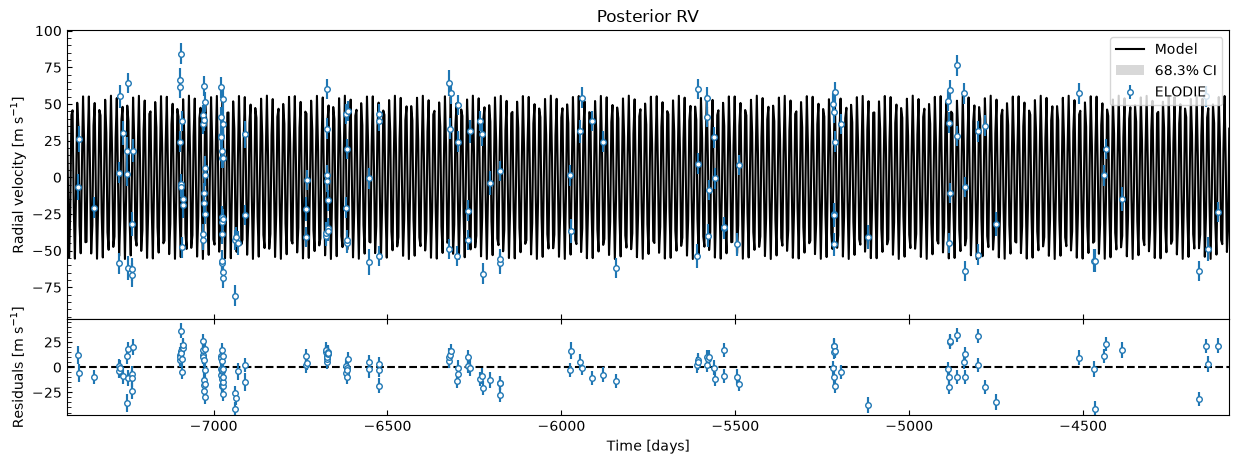

In [ ]:
fitter.plot_posterior_rv(discard_start=nburn, discard_end=0, thin=thin_rate)

Those residuals look okay!

#### Phase-folded RV plot

Like with the MAP, let's do a phase-folded plot again, to get a better look.

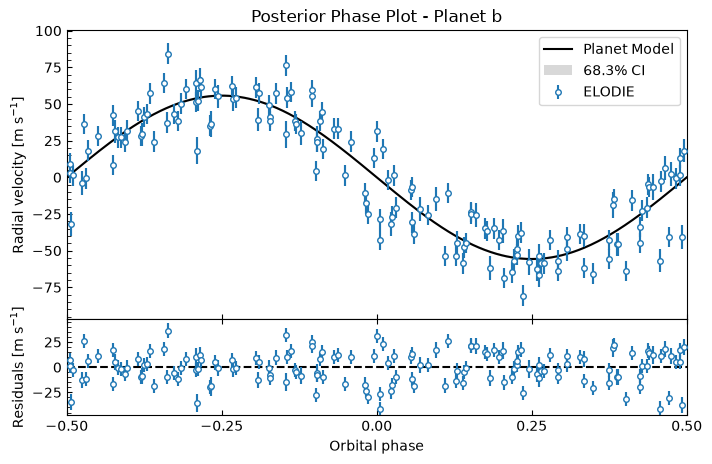

In [ ]:
fitter.plot_posterior_phase("b", discard_start=nburn, discard_end=0, thin=thin_rate)

## Calculate minimum-mass $M_p\sin{i}$
Now that we have fitted for the parameters, we can investigate the $M_p\sin{i}$ of 51 Peg b. To do this, we'll pass in the samples from the `Fitter` for the parameters we need. We also need the stellar mass, which I've again obtained from Birkby et al. 2017. The relationship between planetary mass and RV semi-amplitude is given by

$$ M_p\sin{i}=K\sqrt{1-e^2}\left(\frac{PM^2_*}{2\pi G}\right)^{1/3}. $$

51 peg b Mpsini: 0.48 +0.02 -0.02 M_jupiter


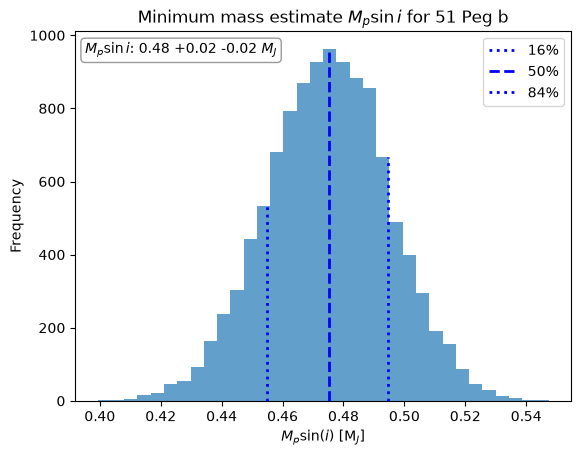

In [ ]:
# Stellar mass values from Birkby et al. 2017
mass_star_val = 1.11  # [M_sun]
mass_star_err = 0.066  # [M_sun]

# Create a distribution to ensure the uncertainty in the stellar mass is captured in the mpsini uncertainty
mass_star = np.random.normal(loc=mass_star_val, scale=mass_star_err, size=len(samples_df))
# Ensure all values in mass_star are positive (incredibly unlikely to be an issue with these values, but just in case)
while any(mass_star <= 0):
    mass_star[mass_star <= 0] = np.random.normal(loc=mass_star_val, scale=mass_star_err, size=sum(mass_star <= 0))

# Get the posterior samples (both free and fixed) as a dictionary
post_samples = fitter.get_mcmc_posterior_dict(discard_start=nburn, thin=thin_rate)

# Calculate the mpsini value - choose whether M_jupiter, M_earth or kg
mpsini = calculate_mpsini(mass_star, post_samples["P_b"], post_samples["K_b"], post_samples["e_b"], unit="M_jupiter")

# Calculate the optimal histogram bin width using Astropy's Knuth bin width
width, edges = knuth_bin_width(mpsini, return_bins=True)

# Let's plot the mpsini posterior distribution in a histogram
fig, ax = plt.subplots(1, 1)
ax.set_title("Minimum mass estimate $M_p\sin{i}$ for 51 Peg b")
ax.set_xlabel("$M_p \sin(i)$ [M$_J$]")
ax.set_ylabel("Frequency")
plot = ax.hist(mpsini, bins=edges, color="tab:blue", alpha=0.7)

# Let's overplot the 16th, 50th and 84th percentiles
ps = np.percentile(mpsini, [16, 50, 84])
# Search for the heights of the bins in which the percentiles are located
heights = plot[0][np.searchsorted(plot[1], ps, side='left')-1]
# The line height will be bin-height / y_bound
_, ymax = ax.get_ybound()
ax.axvline(ps[0], label='16%', color='blue', linestyle=':', linewidth=2, ymax=heights[0] / ymax)
ax.axvline(ps[1], label='50%', color='blue', linestyle='--', linewidth=2, ymax=heights[1] / ymax)
ax.axvline(ps[2], label='84%', color='blue', linestyle=':', linewidth=2, ymax=heights[2] / ymax)

# print the mass to two decimal places with +- uncertainties (the 16 84 percentiles) in a box in top left
ax.text(0.02, 0.97, f"$M_{{p}}\sin{{i}}$: {ps[1]:.2f} +{ps[2]-ps[1]:.2f} -{ps[1]-ps[0]:.2f} $M_{{J}}$", transform=ax.transAxes, fontsize=10, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8))
plt.legend(loc="upper right")
print(f"51 peg b Mpsini: {ps[1]:.2f} +{ps[2]-ps[1]:.2f} -{ps[1]-ps[0]:.2f} M_jupiter")